**1. Ответь на вопросы**

**1.1 Выведите аналитическое решение задачи регрессии. Используйте векторную форму уравнения.**

В линейной регрессии прогноз строится как линейная комбинация признаков:
$$\hat{y}(\mathbf{x}) = w_0 + w_1 x^1 + \dots + w_D x^D $$
То же самое можно записать проще:
$$\hat{y}(\mathbf{x}) = \mathbf{x}^T \mathbf{w} $$
где $\mathbf{x} = \begin{pmatrix} 1 \\ x^1 \\ \dots \\ x^D \end{pmatrix}$, $\mathbf{w} = \begin{pmatrix} w_0 \\ w_1 \\ \dots \\ w_D \end{pmatrix}$
 Рассмотрим теперь функцию ошибки $L(\mathbf{w}) = \left\lVert X\mathbf{w} - Y \right\rVert^2 = \sum_{i=1}^{n} (\hat{y_i}- y_i)^2=\sum_{i=1}^{n}(\mathbf{x}_i^T \mathbf{w}-y_i)^2 $, где $X$ - матрица "объект-признак", $X = \begin{pmatrix} 1 &x_1^1 & x_1^2 & \dots &x_1^D \\ 1 & x_2^1 & x_2^2 & \dots & x_2^D \\ \vdots & \vdots & \vdots & \ddots & \vdots \\ 1 & x_n^1 & x_n^2 & \cdots & x_n^D\end{pmatrix}$, Y - столбец "истинных" значений (таргетов), $Y = \begin{pmatrix} y_1 \\ y_2 \\ \cdots \\ y_n \end{pmatrix}$  
Необходимым и достаточным условием минимума потерь будет равенство нулю градиента: $\nabla L(\mathbf{w}) = \begin{pmatrix} \frac{\partial L}{\partial w_0} \\ \frac{\partial L}{\partial w_1} \\ \cdots \\ \frac{\partial L}{\partial w_D} \end{pmatrix} = 0$. $\nabla L(\mathbf{\hat{w}}) = 2\sum_{i=1}^{n}\mathbf{x}_i(\mathbf{x}_i^T \mathbf{\hat{w}}-y_i) = 0$. Тогда $\sum_{i=1}^{n}\mathbf{x}_i\mathbf{x}_i^T\mathbf{\hat{w}}=\sum_{i=1}^{n} \mathbf{x}_i y_i$. То есть $X^TX\mathbf{\hat{w}}=X^TY$. Отсюда $\mathbf{\hat{w}}=(X^TX)^{-1}X^TY$



**1.2. Какие изменения произойдут в решении при добавлении L1- и L2-регуляризации к функции потерь?**

Регуляризация моделей (model regularization) - распространённый приём в машинном обучении, позволяющий контролировать сложность получаемой модели (model complexity) за счёт внесения ограничений в её настройку. Под сложностью модели в этой книге будет подразумеваться её гибкость, т.е. способность подстаиваться под наблюдения обучающей выборки. Например, полином - более сложная функция, чем линейная, поскольку за счёт большего числа настраиваемых коэффициентов способен гибче настраиваться на регрессионную зависимость.

Существуют разные способы регуляризации, но самый популярный - добавление регуляризующего слагаемого в минимизируемую функцию потерь:
$$L(\mathbf{w}|X, Y) = \sum_{n=1}^{N} \mathcal{L}(f_\mathbf{w}(\mathbf{x}_n), y_n) + \lambda R(\mathbf{w}) \rightarrow \min\limits_{w}$$
Или то же самое для линейной модели:
$$ L(\mathbf{w}|X,Y) = \sum_{n=1}^{N}(\mathbf{x}_n^T \mathbf{w} - y_n)^2 + \lambda R(\mathbf{w}) \rightarrow \min\limits_{w} $$
$$\text{L2-регуляризация: } R(\mathbf{w}) = \sum_{d=1}^{D}w_d^2
\text{, L1-регуляризация: } R(\mathbf{w}) = \sum_{d=1}^{D}|w_d| $$
$$L_{Ridge}(\mathbf{w}) = \| X\mathbf{w}-Y \|_2^2 + \lambda \| \mathbf{w} \|_2^2 $$
$$L_{Lasso}(\mathbf{w}) = \|X\mathbf{w} - Y\|_2^2 + \lambda \|\mathbf{w}\|_1$$
Заметим, что функция модуля не дифференцируемая - поэтому у L1 регуляризации нет аналитического решения. Вычислим градиент $R(\mathbf{w})$ функции $L_{Ridge}$ по $\mathbf{w}$:
$$\nabla R(\mathbf{w}) = \begin{pmatrix} \frac{\partial R}{\partial w_0} \\ \frac{\partial R}{\partial w_1} \\ \cdots \\ \frac{\partial R}{\partial w_D}\end{pmatrix}=\begin{pmatrix} \frac{\partial (w_1^2+\cdots+w_D^2)}{\partial w_0}\\ \frac{\partial (w_1^2+\cdots+w_D^2)}{\partial w_1} \\ \cdots \\ \frac{\partial (w_1^2+\cdots+w_D^2)}{\partial w_D}\end{pmatrix}=\begin{pmatrix} 0 \\ 2w_1 \\ 2 w_2 \\ \cdots \\ 2w_D\end{pmatrix}=2I_0\mathbf{w} \text{ , где } I_0=\begin{pmatrix} 0 & 0 & \cdots & 0 \\ 0 & 1 & \cdots & 0 \\ \vdots &\vdots &\ddots &\vdots \\ 0 & 0 & \cdots & 1\end{pmatrix}$$
Понятно, что прибавляя $R(\mathbf{w})$ к исходной функции ошибок мы получим дифференцируемую функцию, с линейным градиентом.
Итак, $\nabla L_{Ridge}(\mathbf{w})=2\sum_{i=1}^{n}(\mathbf{x}_i\mathbf{x}_i^T\mathbf{w}-\mathbf{x}_iy_i)+2\lambda I_0\mathbf{w}=2(X^TX\mathbf{w}-X^TY+\lambda I_0\mathbf{w})=0. \text{ Отсюда:}$
$$\mathbf{w}= (X^TX+\lambda I_0)^{-1}X^TY$$



**1.3. Объясните, почему L1-регуляризация часто используется для отбора признаков. Почему после обучения модели остается много весов, равных 0**

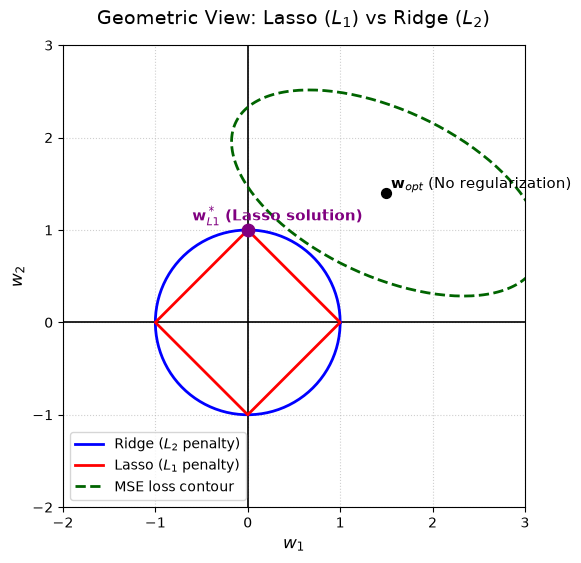

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Настройка красивого стиля
plt.figure(figsize=(10, 6))
ax = plt.gca()

# 1. Оси координат
ax.axhline(0, color='black', linewidth=1.2)
ax.axvline(0, color='black', linewidth=1.2)

# 2. Область L2 (Ridge) — Окружность с радиусом 1
theta = np.linspace(0, 2*np.pi, 200)
x_circle = np.cos(theta)
y_circle = np.sin(theta)
ax.plot(x_circle, y_circle, label=r'Ridge ($L_2$ penalty)', color='blue', linewidth=2)

# 3. Область L1 (Lasso) — Ромб
x_diamond = [0, 1, 0, -1, 0]
y_diamond = [1, 0, -1, 0, 1]
ax.plot(x_diamond, y_diamond, label=r'Lasso ($L_1$ penalty)', color='red', linewidth=2)

# 4. Линия уровня MSE (Эллипс ошибок)
# Задаем параметры эллипса так, чтобы он коснулся вершины ромба в точке (0, 1)
t = np.linspace(0, 2*np.pi, 200)
x_ell = 1.8 * np.cos(t) + 1.5
y_ell = 0.9 * np.sin(t) + 1.4

# Поворачиваем эллипс для наглядности
angle = np.radians(-25)
R = np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])
ell_rotated = R @ np.vstack([x_ell - 1.5, y_ell - 1.4])
x_ell_rot = ell_rotated[0, :] + 1.5
y_ell_rot = ell_rotated[1, :] + 1.4

ax.plot(x_ell_rot, y_ell_rot, label='MSE loss contour', color='darkgreen', linestyle='--', linewidth=2)

# 5. Ключевые точки
ax.scatter(1.5, 1.4, color='black', s=50, zorder=5)
ax.text(1.55, 1.45, r'$\mathbf{w}_{opt}$ (No regularization)', fontsize=11)

# Точка касания ромба (на оси, значит один из весов занулен!)
ax.scatter(0, 1, color='purple', s=80, zorder=5)
ax.text(-0.6, 1.1, r'$\mathbf{w}^*_{L1}$ (Lasso solution)', color='purple', fontsize=11, fontweight='bold')

# Настройки отображения
ax.set_xlim(-2, 3)
ax.set_ylim(-2, 3)
ax.set_xlabel(r'$w_1$', fontsize=12)
ax.set_ylabel(r'$w_2$', fontsize=12)
ax.set_title('Geometric View: Lasso ($L_1$) vs Ridge ($L_2$)', fontsize=14, pad=15)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='lower left', fontsize=10)
ax.set_aspect('equal')

plt.show()

На рисунке кругом и ромбом обозначены области возможных значений параметра $\mathbf{w}$, а эллипсом - линии уровня функции ошибки MSE. Можно догадаться, что вероятность пересечения эллипса и круга по точке с одной из компанент веса равной нулю $\mathbf{w}_i=0$,  $i \in {\set{1, 2}}$, а вероятность пересечения эллипса и ромба по вершине ромба достаточно большая. Формальное доказательство использует субдифференциал.

**1.4. Объясните, как можно использовать те же модели (линейная регрессия, гребневая регрессия и т. д.), но при этом обеспечить возможность учета нелинейных зависимостей.**

Пусть для простоты сначала есть только один исходный признак $x$ и уравнение линейной регрессии примет вид $\hat{y}=w_0+w_1x$. Можно искуственно создать для него новые признаки $x^2$, $x^3$, $\cdots$, $x^M$ Тогда уравнение линейной регрессии превратится в полином: $\hat{y}(x)=w_0+w_1x+w_2x^2+\cdots+w_Mx^M$.То есть модель считает $x^2$, $x^3$, $\cdots$ независимыми переменными. Если признаков несколько - $x_1$, $x_2$, то в сумму добавятся их попарные произведения - $x_1x_2$. Можно пойти еще дальше и вместо вектора признаков $\mathbf{x}$ взять вектор из любых функций:
$$\mathbf{x} \longrightarrow \phi(\mathbf{x})=\begin{pmatrix}1 \\ \phi_1(\mathbf{x}) \\ \phi_2(\mathbf{x}) \\ \cdots \\ \phi_M(\mathbf{x})\end{pmatrix}$$
Тогда прогноз строится как:
$$\hat{y}(\mathbf{x}) = \sum_{j=0}^{M} w_j \phi_j(\mathbf{x}) = \boldsymbol{\phi}(\mathbf{x})^T \mathbf{w}$$
Здесь возникает проблема: если перейти, например, к слишком большим степеням полинома - возникнет переобучение. Избежать этого может помочь Ridge и Lasso:  
Запускаем Ridge, и он штрафует модель за слишком резкие изгибы, удерживая веса маленькими. Кривая становится плавной.  
Запускаем Lasso, и он из огромного полинома (например, 10-й степени) выбирает только те степени, которые реально нужны для описания данных, зануляя веса у лишних степеней.


**2.Введение — выполните всю предварительную обработку данных из предыдущего урока.**

**2.1 Импорт библиотек.**

**2.2 Ознакомьтесь с материалами по обучению и тестированию.**

In [1]:
import numpy as np
import pandas as pd
df_train = pd.read_json("data/train.json")
df_test = pd.read_json("data/test.json")
df_train.columns

Index(['bathrooms', 'bedrooms', 'building_id', 'created', 'description',
       'display_address', 'features', 'latitude', 'listing_id', 'longitude',
       'manager_id', 'photos', 'price', 'street_address', 'interest_level'],
      dtype='str')

**3. Введение в анализ данных, часть 2**

**3.1 Давайте создадим дополнительные характеристики для повышения качества модели. Рассмотрим столбец под названием «features». Он содержит список основных особенностей текущей квартиры.**

**3.2 Удалите из столбца неиспользуемые символы ([,], ', ", и пробел).**

**3.3 Получите все значения в каждом списке и соберите результат в один большой список для всего набора данных. Для этого можно использовать DataFrame.iterrows().**

In [2]:
import re

def clean_features(current_features):
    cleaned_list = []
    if isinstance(current_features, list):
        for item in current_features:
            cleaned_item = re.sub(r"[\[\]'\"\s]", "", item)
            if cleaned_item:
                cleaned_list.append(cleaned_item)
    return cleaned_list

huge_list = []
for index, row in df_train.iterrows():
    cleaned_list = clean_features(row['features'])
    df_train.at[index, 'features'] = cleaned_list
    huge_list.extend(cleaned_list)

df_test['features'] = df_test['features'].apply(clean_features)

**3.4 Сколько уникальных значений содержит список результатов?**

In [3]:
unique_values_count = len(set(huge_list))
print(f"Количество уникальных значений: {unique_values_count}")

Количество уникальных значений: 1545


**3.5 Составьте список самых популярных функций из нашего обширного перечня и выберите 20 лучших на данный момент.**

**3.6 Если все правильно, вы должны получить следующие значения: 'Elevator', 'CatsAllowed', 'HardwoodFloors', 'DogsAllowed', 'Doorman', 'Dishwasher', 'NoFee', 'LaundryinBuilding', 'FitnessCenter', 'Pre-War', 'LaundryinUnit', 'RoofDeck', 'OutdoorSpace', 'DiningRoom', 'HighSpeedInternet', 'Balcony', 'SwimmingPool', 'LaundryInBuilding', 'NewConstruction', 'Terrace'.**

**3.7 Теперь создайте 20 новых объектов на основе 20 наиболее часто встречающихся значений: 1, если значение находится в столбце "Объект", в противном случае 0.**

In [4]:
from collections import Counter
feature_counter = Counter(huge_list)
top_20_with_counts = feature_counter.most_common(20)
top_20_features = [item[0] for item in top_20_with_counts]
top_20_with_counts

[('Elevator', 25915),
 ('CatsAllowed', 23540),
 ('HardwoodFloors', 23527),
 ('DogsAllowed', 22035),
 ('Doorman', 20898),
 ('Dishwasher', 20426),
 ('NoFee', 18062),
 ('LaundryinBuilding', 16344),
 ('FitnessCenter', 13252),
 ('Pre-War', 9148),
 ('LaundryinUnit', 8738),
 ('RoofDeck', 6542),
 ('OutdoorSpace', 5268),
 ('DiningRoom', 5136),
 ('HighSpeedInternet', 4299),
 ('Balcony', 2992),
 ('SwimmingPool', 2730),
 ('LaundryInBuilding', 2593),
 ('NewConstruction', 2559),
 ('Terrace', 2283)]

**3.8 Расширьте наш набор признаков, добавив «ванные комнаты», «спальни», и создайте специальную переменную feature_list со всеми названиями признаков. Теперь у нас есть 22 значения. Все модели должны быть обучены на этих 22 признаках.**

In [5]:
for feature in top_20_features:
    df_train[feature] = df_train['features'].apply(lambda x: 1 if feature in x else 0)
feature_list = ['bathrooms', 'bedrooms'] + top_20_features
print(f"Количество признаков в списке: {len(feature_list)}")
print("\nФинальный feature_list для обучения моделей:")
print(feature_list)
df_train[['bathrooms', 'bedrooms'] + top_20_features[:3]].head()
for feature in top_20_features:
    df_test[feature] = df_test['features'].apply(lambda x: 1 if feature in x else 0)

Количество признаков в списке: 22

Финальный feature_list для обучения моделей:
['bathrooms', 'bedrooms', 'Elevator', 'CatsAllowed', 'HardwoodFloors', 'DogsAllowed', 'Doorman', 'Dishwasher', 'NoFee', 'LaundryinBuilding', 'FitnessCenter', 'Pre-War', 'LaundryinUnit', 'RoofDeck', 'OutdoorSpace', 'DiningRoom', 'HighSpeedInternet', 'Balcony', 'SwimmingPool', 'LaundryInBuilding', 'NewConstruction', 'Terrace']


In [6]:
print("=== Статистика по цене (price) ===")
print(df_train['price'].describe())
print("\nТоп-10 самых высоких цен:")
print(df_train['price'].sort_values(ascending=False).head(10))
print("\nТоп-10 самых низких цен:")
print(df_train['price'].sort_values(ascending=True).head(10))

print("\n=== Статистика по bathrooms ===")
print(df_train['bathrooms'].describe())
print(df_train['bathrooms'].value_counts().sort_index())

print("\n=== Статистика по bedrooms ===")
print(df_train['bedrooms'].describe())
print(df_train['bedrooms'].value_counts().sort_index())

=== Статистика по цене (price) ===
count    4.935200e+04
mean     3.830174e+03
std      2.206687e+04
min      4.300000e+01
25%      2.500000e+03
50%      3.150000e+03
75%      4.100000e+03
max      4.490000e+06
Name: price, dtype: float64

Топ-10 самых высоких цен:
32611     4490000
12168     1150000
55437     1070000
57803     1070000
123877     135000
4620       111111
91709      100000
54148       90000
116586      85000
96905       80000
Name: price, dtype: int64

Топ-10 самых низких цен:
53144      43
87511      45
117339    401
113552    695
85617     695
113599    695
102756    695
22693     700
109164    800
61138     868
Name: price, dtype: int64

=== Статистика по bathrooms ===
count    49352.00000
mean         1.21218
std          0.50142
min          0.00000
25%          1.00000
50%          1.00000
75%          1.00000
max         10.00000
Name: bathrooms, dtype: float64
bathrooms
0.0       313
1.0     39422
1.5       645
2.0      7660
2.5       277
3.0       745
3.5      

In [7]:
# Диагностика: сколько строк реально считаются выбросами
print("Train price > 50000:", (df_train['price'] > 80000).sum())
print("Train price < 300:", (df_train['price'] < 300).sum())
print("Train bathrooms > 6:", (df_train['bathrooms'] > 7).sum())

# Фильтрация физически нереалистичных значений (не "неудобных", а именно ошибочных)
df_train = df_train[
    (df_train['price'] >= 300) & (df_train['price'] <= 50000) &
    (df_train['bathrooms'] <= 6)
].reset_index(drop=True)

df_test = df_test[
    (df_test['price'] >= 300) & (df_test['price'] <= 50000) &
    (df_test['bathrooms'] <= 6)
].reset_index(drop=True)

print(f"Train: осталось {len(df_train)} строк")
print(f"Test: осталось {len(df_test)} строк")

Train price > 50000: 9
Train price < 300: 2
Train bathrooms > 6: 1
Train: осталось 49332 строк
Test: осталось 74638 строк


**4.1 Реализуйте класс Python для алгоритма линейной регрессии с двумя основными методами — fit и predict. Используйте стохастический градиентный спуск (SGD) для поиска оптимальных весов модели. Для лучшего понимания рекомендуем реализовать отдельные версии алгоритма с аналитическим решением и нестохастическим градиентным спуском.**

**4.2 Что такое детерминированная модель? Сделайте SGD детерминированным.**

In [8]:
class MyLinearRegression:
    def __init__(self, method='sgd', lr=0.001, epochs=5, alpha=1, l1_ratio=0.5, penalty=None):
        self.method = method
        self.w = None
        self.lr = lr
        self.epochs = epochs
        self.alpha = alpha
        self.l1_ratio = l1_ratio
        self.penalty = penalty


    def fit(self, x, y):
        X = x.values
        Y = y.values
        X_bias = np.hstack([np.ones((X.shape[0], 1)), X])
        n_samples = X.shape[0]
        np.random.seed(42)
        if self.method == 'analytical':
            self.w = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ Y
        elif self.method == 'gd':
            self.w = np.zeros(X_bias.shape[1])
            for i in range(1000):
                gradient = (2/X_bias.shape[0]) * X_bias.T @ (X_bias @ self.w - Y)
                self.w = self.w - self.lr * gradient

        elif self.method == 'sgd':
            self.w = np.zeros(X_bias.shape[1])
            reg_alpha = self.alpha / n_samples
            max_grad_norm = 1e3  # ограничение на длину шага градиента
            for epoch in range(self.epochs):
                shuffled_indices = np.random.permutation(n_samples)
                for i in shuffled_indices:
                    x_sample = X_bias[i]
                    y_sample = Y[i]
                    gradient = 2 * x_sample * (x_sample @ self.w - y_sample)
                    w_reg = self.w.copy()
                    w_reg[0] = 0
                    if self.penalty == 'l2':
                        gradient += reg_alpha * w_reg
                    elif self.penalty == 'l1':
                        gradient += reg_alpha * np.sign(w_reg)
                    elif self.penalty == 'elasticnet':
                        l1_penalty = self.l1_ratio * reg_alpha * np.sign(w_reg)
                        l2_penalty = (1 - self.l1_ratio) * reg_alpha * w_reg
                        gradient += l1_penalty + l2_penalty

                    grad_norm = np.linalg.norm(gradient)
                    if grad_norm > max_grad_norm:
                        gradient = gradient * (max_grad_norm / grad_norm)

                    self.w = self.w - self.lr * gradient
                    self.w = np.clip(self.w, -1e8, 1e8)

            

    def predict(self, x):
        X = x.values
        X_bias = np.hstack([np.ones((X.shape[0], 1)), X])
        return X_bias @ self.w


**4.3 Определите коэффициент R² (R²) и реализуйте функцию для его вычисления.**

In [9]:
def R2(y_real, y_pred):
    return 1 - np.sum((y_real - y_pred) ** 2) / np.sum((y_real - y_real.mean()) ** 2)

**4.4 С помощью вашего алгоритма сделайте прогнозы и оцените модель, используя метрики MAE, RMSE и R2.**

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
x_train = df_train[feature_list]
y_train = df_train['price']
my_model = MyLinearRegression(method='analytical')
my_model.fit(x_train, y_train)
y_analytic_pred_train = my_model.predict(x_train)
analytic_mae_train = mean_absolute_error(y_train, y_analytic_pred_train)
analytic_rmse_train = np.sqrt(mean_squared_error(y_train, y_analytic_pred_train))
analytic_r2_train = R2(y_train, y_analytic_pred_train)
x_test = df_test[feature_list]
y_test = df_test['price']
y_analytic_pred_test = my_model.predict(x_test)
analytic_mae_test = mean_absolute_error(y_test, y_analytic_pred_test)
analytic_rmse_test = np.sqrt(mean_squared_error(y_test, y_analytic_pred_test))
analytic_r2_test = R2(y_test, y_analytic_pred_test)

In [11]:
gd_model = MyLinearRegression(method='gd', lr=0.001)
gd_model.fit(x_train, y_train)
y_gd_pred_train = gd_model.predict(x_train)
y_gd_pred_test = gd_model.predict(x_test)
gd_mae_train = mean_absolute_error(y_train, y_gd_pred_train)
gd_mae_test = mean_absolute_error(y_test, y_gd_pred_test)
gd_rmse_train = np.sqrt(mean_squared_error(y_train, y_gd_pred_train))
gd_rmse_test = np.sqrt(mean_squared_error(y_test, y_gd_pred_test))
gd_r2_train = R2(y_train, y_gd_pred_train)
gd_r2_test = R2(y_test, y_gd_pred_test)

In [12]:
my_model = MyLinearRegression(method='sgd')
my_model.fit(x_train, y_train)
y_sgd_pred_train = my_model.predict(x_train)
sgd_mae_train = mean_absolute_error(y_train, y_sgd_pred_train)
sgd_rmse_train = np.sqrt(mean_squared_error(y_train, y_sgd_pred_train))
sgd_r2_train = R2(y_train, y_sgd_pred_train)
sgd_pred_test = my_model.predict(x_test)
sgd_mae_test = mean_absolute_error(y_test, sgd_pred_test)
sgd_rmse_test = np.sqrt(mean_squared_error(y_test, sgd_pred_test))
sgd_r2_test = R2(y_test, sgd_pred_test)

**4.5 Инициализируйте функцию LinearRegression() из sklearn.linear_model, обучите модель и выполните прогнозирование для обучающей и тестовой частей, как в предыдущем уроке.**

In [13]:
from sklearn.linear_model import LinearRegression
sk_model = LinearRegression()
sk_model.fit(x_train, y_train)
sk_pred_train = sk_model.predict(x_train)
sk_pred_test = sk_model.predict(x_test)
sk_mae_train = mean_absolute_error(y_train, sk_pred_train)
sk_rmse_train = np.sqrt(mean_squared_error(y_train, sk_pred_train))
sk_r2_train = sk_model.score(x_train, y_train)
sk_mae_test = mean_absolute_error(y_test, sk_pred_test)
sk_rmse_test = np.sqrt(mean_squared_error(y_test, sk_pred_test))
sk_r2_test = sk_model.score(x_test, y_test)

**4.6 Сравните показатели качества и убедитесь, что разница невелика (между вашей реализацией и sklearn).**

**4.7 Сохраните метрики, как и в предыдущем уроке, в таблице со столбцами model, train, test для таблицы MAE, таблицы RMSE и коэффициента R2.**

In [14]:
mae_table = pd.DataFrame({
    'model': ['My_Analytical', 'My_SGD', 'My_GD_Full', 'Sklearn_Linear'],
    'train': [analytic_mae_train, sgd_mae_train, gd_mae_train, sk_mae_train],
    'test': [analytic_mae_test, sgd_mae_test, gd_mae_test, sk_mae_test]
})

rmse_table = pd.DataFrame({
    'model': ['My_Analytical', 'My_SGD', 'My_GD_Full', 'Sklearn_Linear'],
    'train': [analytic_rmse_train, sgd_rmse_train, gd_rmse_train, sk_rmse_train],
    'test': [analytic_rmse_test, sgd_rmse_test, gd_rmse_test, sk_rmse_test]
})

r2_table = pd.DataFrame({
    'model': ['My_Analytical', 'My_SGD', 'My_GD_Full', 'Sklearn_Linear'],
    'train': [analytic_r2_train, sgd_r2_train, gd_r2_train, sk_r2_train],
    'test': [analytic_r2_test, sgd_r2_test, gd_r2_test, sk_r2_test]
})

print("--- Метрики MAE ---")
display(mae_table)

print("\n--- Метрики RMSE ---")
display(rmse_table)

print("\n--- Коэффициент R2 ---")
display(r2_table)

--- Метрики MAE ---


,model,train,test
0,My_Analytical,839.361503,848.427810
1,My_SGD,797.387816,805.962849
2,My_GD_Full,887.134106,893.434433
3,Sklearn_Linear,839.361503,848.427810



--- Метрики RMSE ---


,model,train,test
0,My_Analytical,1477.777149,1533.068300
1,My_SGD,1585.327781,1640.367200
2,My_GD_Full,1611.971826,1665.971601
3,Sklearn_Linear,1477.777149,1533.068300



--- Коэффициент R2 ---


,model,train,test
0,My_Analytical,0.557552,0.541392
1,My_SGD,0.490807,0.474950
2,My_GD_Full,0.473548,0.458431
3,Sklearn_Linear,0.557552,0.541392


**5 Реализация моделей с регуляризацией — Ridge, Lasso, ElasticNet**

**5.1 Реализуйте алгоритмы Ridge, Lasso и ElasticNet: расширьте функцию потерь с помощью L2, L1 и обеих регуляризаций соответственно.** 
**5.2 С помощью вашего алгоритма сделайте прогнозы и оцените модель, используя метрики MAE, RMSE и R2.** 
**5.3 Инициализируйте функции Ridge(), Lasso() и ElasticNet() из sklearn.linear_model, обучите модель и сделайте прогнозы для обучающей и тестовой выборок, как в предыдущем уроке.**
**5.4 Сравните показатели качества и убедитесь, что разница невелика (между вашими реализациями и sklearn).**
**5.5 Сохраните метрики, как и в предыдущем уроке, в таблице со столбцами model, train, test для таблицы MAE, таблицы RMSE и коэффициента R2.**

In [15]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

model_ridge = MyLinearRegression(method='sgd', penalty='l2', alpha=0.1)
model_lasso = MyLinearRegression(method='sgd', penalty='l1', alpha=0.1)
model_elastic = MyLinearRegression(method='sgd', penalty='elasticnet', alpha=0.1, l1_ratio=0.5)

my_models = [model_ridge, model_lasso, model_elastic]
model_names = ['My_Ridge', 'My_Lasso', 'My_ElasticNet']

my_mae_train, my_mae_test = [], []
my_rmse_train, my_rmse_test = [], []
my_r2_train, my_r2_test = [], []

for model in my_models:
    model.fit(x_train, y_train)
    
    pred_train = model.predict(x_train)
    pred_test = model.predict(x_test)
    
    my_mae_train.append(mean_absolute_error(y_train, pred_train))
    my_mae_test.append(mean_absolute_error(y_test, pred_test))
    
    my_rmse_train.append(np.sqrt(mean_squared_error(y_train, pred_train)))
    my_rmse_test.append(np.sqrt(mean_squared_error(y_test, pred_test)))
    
    my_r2_train.append(R2(y_train, pred_train))
    my_r2_test.append(R2(y_test, pred_test))


sk_ridge = Ridge(alpha=0.1)
sk_lasso = Lasso(alpha=0.1)
sk_elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)

sk_models = [sk_ridge, sk_lasso, sk_elastic]
sk_names = ['Sklearn_Ridge', 'Sklearn_Lasso', 'Sklearn_ElasticNet']

sk_mae_train, sk_mae_test = [], []
sk_rmse_train, sk_rmse_test = [], []
sk_r2_train, sk_r2_test = [], []

for model in sk_models:
    # Обучаем
    model.fit(x_train, y_train)
    
    pred_train = model.predict(x_train)
    pred_test = model.predict(x_test)
    
    # Метрики
    sk_mae_train.append(mean_absolute_error(y_train, pred_train))
    sk_mae_test.append(mean_absolute_error(y_test, pred_test))
    
    sk_rmse_train.append(np.sqrt(mean_squared_error(y_train, pred_train)))
    sk_rmse_test.append(np.sqrt(mean_squared_error(y_test, pred_test)))
    
    sk_r2_train.append(model.score(x_train, y_train))
    sk_r2_test.append(model.score(x_test, y_test))


all_models = model_names + sk_names
all_mae_train = my_mae_train + sk_mae_train
all_mae_test = my_mae_test + sk_mae_test

all_rmse_train = my_rmse_train + sk_rmse_train
all_rmse_test = my_rmse_test + sk_rmse_test

all_r2_train = my_r2_train + sk_r2_train
all_r2_test = my_r2_test + sk_r2_test

reg_mae_table = pd.DataFrame({'model': all_models, 'train': all_mae_train, 'test': all_mae_test})
reg_rmse_table = pd.DataFrame({'model': all_models, 'train': all_rmse_train, 'test': all_rmse_test})
reg_r2_table = pd.DataFrame({'model': all_models, 'train': all_r2_train, 'test': all_r2_test})

print("--- Метрики MAE с регуляризацией ---")
display(reg_mae_table)

print("\n--- Метрики RMSE с регуляризацией ---")
display(reg_rmse_table)

print("\n--- Коэффициент R2 с регуляризацией ---")
display(reg_r2_table)

--- Метрики MAE с регуляризацией ---


,model,train,test
0,My_Ridge,797.388949,805.963957
1,My_Lasso,797.387816,805.962849
2,My_ElasticNet,797.388383,805.963403
3,Sklearn_Ridge,839.359664,848.425924
4,Sklearn_Lasso,839.217802,848.277898
5,Sklearn_ElasticNet,821.732456,830.102968



--- Метрики RMSE с регуляризацией ---


,model,train,test
0,My_Ridge,1585.336966,1640.376226
1,My_Lasso,1585.327786,1640.367205
2,My_ElasticNet,1585.332377,1640.371716
3,Sklearn_Ridge,1477.777149,1533.068350
4,Sklearn_Lasso,1477.778524,1533.066919
5,Sklearn_ElasticNet,1497.267968,1553.140642



--- Коэффициент R2 с регуляризацией ---


,model,train,test
0,My_Ridge,0.490801,0.474944
1,My_Lasso,0.490807,0.474950
2,My_ElasticNet,0.490804,0.474947
3,Sklearn_Ridge,0.557552,0.541392
4,Sklearn_Lasso,0.557551,0.541393
5,Sklearn_ElasticNet,0.545804,0.529304


**6.1 Сначала приведите несколько примеров того, почему и где нормализация признаков является обязательной, и наоборот.**

Нормализация обязательна во всех градиентных методах и в алгоритмах основанных на расстоянии (например, метод К-ближайших соседей — KNN, или метод опорных векторов — SVM). Если не масштабировать данные, признак с большими числами (например, площадь в кв. футах) полностью затмит признак с маленькими числами (количество санузлов), хотя оба они важны. Нормализация не нужна в моделях на основе деревьев решений (Decision Tree, Random Forest, XGBoost). Деревья просто делят выборку по порогам (например, «площадь больше 50»), и им абсолютно всё равно, в каких единицах измеряется признак. Также она не влияет на точное аналитическое решение линейной регрессии (МНК), которое мы писали в самом начале.

**6.2 Рассмотрим первый из классических методов нормализации — MinMaxScaler. Запишите математическую формулу для этого метода.**

Рассмотрим один из столбцов в матрице DataFrame. Пусть $x_{min}$ и $x_{max}$ - минимальное и максимальное значение элементов в этом столбце соответсвенно. Тогда для каждого значения $x$ в матрице можно применить преобразование:
$$x \rightarrow x_{new}, \text{ } x_{new} = \frac{x - x_{min}}{x_{max} - x_{min}}$$
Такое преобразования называется MinMaxScaler

**6.3 Реализуйте собственную функцию или класс для нормализации признаков с помощью MinMaxScaler.**

In [16]:
class MyMinMaxScaler:
    def __init__(self):
        self.min_ = None
        self.max_ = None
    
    def fit(self, X):
        self.min_ = np.min(X, axis=0)
        self.max_ = np.max(X, axis=0)
        return self
    
    def transform(self, X):
        return (X - self.min_) / (self.max_ - self.min_ + 1e-8)
    
    def fit_transform(self, X):
        return self.fit(X).transform(X)



**6.4 Инициализируйте функцию MinMaxScaler() из sklearn.preprocessing.**
**6.5 Сравните результаты нормализации признаков, полученные с помощью вашего собственного метода и метода sklearn.**

In [17]:
from sklearn.preprocessing import MinMaxScaler

X_sample = df_train[feature_list]

my_scaler = MyMinMaxScaler()
X_my_scaled = my_scaler.fit_transform(X_sample)

sk_scaler = MinMaxScaler()
X_sk_scaled = sk_scaler.fit_transform(X_sample)

difference_close = np.allclose(X_my_scaled, X_sk_scaled)

print(f"Матрицы нормализации совпадают? {difference_close}")

display(pd.DataFrame(X_my_scaled, columns=feature_list).head(3))

Матрицы нормализации совпадают? True


,bathrooms,bedrooms,Elevator,CatsAllowed,HardwoodFloors,DogsAllowed,Doorman,Dishwasher,NoFee,LaundryinBuilding,...,LaundryinUnit,RoofDeck,OutdoorSpace,DiningRoom,HighSpeedInternet,Balcony,SwimmingPool,LaundryInBuilding,NewConstruction,Terrace
0,0.166667,0.125,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.166667,0.250,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.166667,0.250,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**6.6 Повторите шаги с b по e для другого метода нормализации — StandardScaler.**
Снова рассмотрим один из столбцов в матрице. Для каждого $x$ из столбца:
$$x \rightarrow x_{new} = \frac{x - \mu}{\sigma}$$
где $\mu = \sum_{i = 1}^N x_i$, $\sigma = \sqrt{\frac{1}{N}\sum_{i=1}^{N}(x_i-\mu)^2}$  
Такое преобразование называется StandardScaler


In [18]:
class MyStandardScaler:
    def __init__(self):
        self.mean_ = None
        self.scale_ = None 

    def fit(self, X):
        self.mean_ = np.mean(X, axis=0)
        self.scale_ = np.std(X, axis=0)
        return self

    def transform(self, X):
        return (X - self.mean_) / (self.scale_ + 1e-8)

    def fit_transform(self, X):
        return self.fit(X).transform(X)

In [19]:
from sklearn.preprocessing import StandardScaler

X_sample = df_train[feature_list]

my_std_scaler = MyStandardScaler()
X_my_std_scaled = my_std_scaler.fit_transform(X_sample)

sk_std_scaler = StandardScaler()
X_sk_std_scaled = sk_std_scaler.fit_transform(X_sample)

std_difference_close = np.allclose(X_my_std_scaled, X_sk_std_scaled)

print(f"Матрицы StandardScaler совпадают? {std_difference_close}")

display(pd.DataFrame(X_my_std_scaled, columns=feature_list).head(3))

Матрицы StandardScaler совпадают? True


,bathrooms,bedrooms,Elevator,CatsAllowed,HardwoodFloors,DogsAllowed,Doorman,Dishwasher,NoFee,LaundryinBuilding,...,LaundryinUnit,RoofDeck,OutdoorSpace,DiningRoom,HighSpeedInternet,Balcony,SwimmingPool,LaundryInBuilding,NewConstruction,Terrace
0,-0.425152,-0.485796,-1.051388,1.047252,1.047379,1.113563,-0.856874,1.189703,-0.760009,1.420818,...,-0.463890,-0.390972,-0.345728,2.933452,-0.308932,-0.254054,-0.241989,-0.23549,-0.233904,-0.22018
1,-0.425152,0.411578,0.951124,-0.954880,1.047379,-0.898019,1.167033,1.189703,1.315773,1.420818,...,-0.463890,-0.390972,-0.345728,-0.340895,-0.308932,-0.254054,-0.241989,-0.23549,-0.233904,-0.22018
2,-0.425152,0.411578,0.951124,-0.954880,1.047379,-0.898019,1.167033,1.189703,-0.760009,1.420818,...,2.155685,-0.390972,-0.345728,-0.340895,-0.308932,-0.254054,-0.241989,-0.23549,-0.233904,-0.22018


**7 Обучите пользовательские модели и модели sklearn на нормализованных данных.
7.1 Для всех моделей — линейной регрессии, гребневой регрессии, лассо и ElasticNet — используйте MinMaxScaler.
7.2 Для построения всех моделей — линейной регрессии, гребневой регрессии, лассо и ElasticNet — используйте StandardScaler.
7.3 Добавьте все результаты в наш датафрейм с метриками по образцам.**

In [20]:
minmax_scaler = MyMinMaxScaler()
X_train_mm = pd.DataFrame(minmax_scaler.fit_transform(x_train), columns=feature_list)
X_test_mm = pd.DataFrame(minmax_scaler.transform(x_test), columns=feature_list)

std_scaler = MyStandardScaler()
X_train_std = pd.DataFrame(std_scaler.fit_transform(x_train), columns=feature_list)
X_test_std = pd.DataFrame(std_scaler.transform(x_test), columns=feature_list)


def evaluate_all_models(X_tr, X_te, y_tr, y_te, scaling_name):
    """
    Функция обучает все 10 моделей на заданном наборе данных
    и возвращает список с результатами метрик.
    """
    models = {
        'My_Analytical': MyLinearRegression(method='analytical'),
        'My_GD': MyLinearRegression(method='gd', lr=0.001),
        'My_SGD': MyLinearRegression(method='sgd', lr=0.001),
        'My_Ridge': MyLinearRegression(method='sgd', penalty='l2', alpha=0.1),
        'My_Lasso': MyLinearRegression(method='sgd', penalty='l1', alpha=0.1),
        'My_ElasticNet': MyLinearRegression(method='sgd', penalty='elasticnet', alpha=0.1, l1_ratio=0.5),
        'Sklearn_Linear': LinearRegression(),
        'Sklearn_Ridge': Ridge(alpha=0.1),
        'Sklearn_Lasso': Lasso(alpha=0.1),
        'Sklearn_ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5)
    }
    
    rows = []
    
    for name, model in models.items():
        model.fit(X_tr, y_tr)
        pred_tr = model.predict(X_tr)
        pred_te = model.predict(X_te)
        
        mae_tr = mean_absolute_error(y_tr, pred_tr)
        mae_te = mean_absolute_error(y_te, pred_te)
        
        rmse_tr = np.sqrt(mean_squared_error(y_tr, pred_tr))
        rmse_te = np.sqrt(mean_squared_error(y_te, pred_te))

        r2_tr = R2(y_tr, pred_tr)
        r2_te = R2(y_te, pred_te)
        
        rows.append({
            'model': name,
            'scaler': scaling_name,
            'mae_train': mae_tr,
            'mae_test': mae_te,
            'rmse_train': rmse_tr,
            'rmse_test': rmse_te,
            'r2_train': r2_tr,
            'r2_test': r2_te
        })
        
    return rows

results_minmax = evaluate_all_models(X_train_mm, X_test_mm, y_train, y_test, 'MinMaxScaler')
results_std = evaluate_all_models(X_train_std, X_test_std, y_train, y_test, 'StandardScaler')

df_all_results = pd.DataFrame(results_minmax + results_std)


mae_table_scaled = df_all_results[['model', 'scaler', 'mae_train', 'mae_test']].rename(
    columns={'mae_train': 'train', 'mae_test': 'test'}
)

rmse_table_scaled = df_all_results[['model', 'scaler', 'rmse_train', 'rmse_test']].rename(
    columns={'rmse_train': 'train', 'rmse_test': 'test'}
)

r2_table_scaled = df_all_results[['model', 'scaler', 'r2_train', 'r2_test']].rename(
    columns={'r2_train': 'train', 'r2_test': 'test'}
)

print("=== Метрики MAE на нормализованных данных ===")
display(mae_table_scaled)

print("\n=== Метрики RMSE на нормализованных данных ===")
display(rmse_table_scaled)

print("\n=== Коэффициент R2 на нормализованных данных ===")
display(r2_table_scaled)

=== Метрики MAE на нормализованных данных ===


,model,scaler,train,test
0,My_Analytical,MinMaxScaler,839.361503,848.427810
1,My_GD,MinMaxScaler,1230.579063,1236.959930
2,My_SGD,MinMaxScaler,865.749059,873.896357
3,My_Ridge,MinMaxScaler,865.760694,873.907917
4,My_Lasso,MinMaxScaler,865.749063,873.896362
5,My_ElasticNet,MinMaxScaler,865.754879,873.902140
6,Sklearn_Linear,MinMaxScaler,839.361503,848.427810
7,Sklearn_Ridge,MinMaxScaler,839.326100,848.391767
8,Sklearn_Lasso,MinMaxScaler,839.126670,848.184172
9,Sklearn_ElasticNet,MinMaxScaler,1016.131240,1021.752750



=== Метрики RMSE на нормализованных данных ===


,model,scaler,train,test
0,My_Analytical,MinMaxScaler,1477.777149,1533.068300
1,My_GD,MinMaxScaler,2132.368823,2176.433321
2,My_SGD,MinMaxScaler,1791.457616,1842.722130
3,My_Ridge,MinMaxScaler,1791.486413,1842.750219
4,My_Lasso,MinMaxScaler,1791.457634,1842.722147
5,My_ElasticNet,MinMaxScaler,1791.472024,1842.736184
6,Sklearn_Linear,MinMaxScaler,1477.777149,1533.068300
7,Sklearn_Ridge,MinMaxScaler,1477.777206,1533.071374
8,Sklearn_Lasso,MinMaxScaler,1477.778930,1533.073753
9,Sklearn_ElasticNet,MinMaxScaler,1854.490969,1902.658553



=== Коэффициент R2 на нормализованных данных ===


,model,scaler,train,test
0,My_Analytical,MinMaxScaler,0.557552,0.541392
1,My_GD,MinMaxScaler,0.078768,0.075707
2,My_SGD,MinMaxScaler,0.349784,0.337420
3,My_Ridge,MinMaxScaler,0.349764,0.337400
4,My_Lasso,MinMaxScaler,0.349784,0.337420
5,My_ElasticNet,MinMaxScaler,0.349774,0.337410
6,Sklearn_Linear,MinMaxScaler,0.557552,0.541392
7,Sklearn_Ridge,MinMaxScaler,0.557552,0.541390
8,Sklearn_Lasso,MinMaxScaler,0.557551,0.541389
9,Sklearn_ElasticNet,MinMaxScaler,0.303223,0.293617


In [21]:
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures

base_features = ['bathrooms', 'bedrooms']
X_tr_base = x_train[base_features]
X_te_base = x_test[base_features]

base_minmax_scaler = MinMaxScaler()
X_tr_base_mm = base_minmax_scaler.fit_transform(X_tr_base)
X_te_base_mm = base_minmax_scaler.transform(X_te_base)

poly = PolynomialFeatures(degree=10, include_bias=False)
X_tr_poly = poly.fit_transform(X_tr_base_mm)
X_te_poly = poly.transform(X_te_base_mm)

poly_scaler = StandardScaler()
X_tr_poly_scaled = poly_scaler.fit_transform(X_tr_poly)
X_te_poly_scaled = poly_scaler.transform(X_te_poly)

print(f"Количество признаков до полиномов: {X_tr_base.shape[1]}")
print(f"Количество признаков после PolynomialFeatures(degree=10): {X_tr_poly_scaled.shape[1]}")

Количество признаков до полиномов: 2
Количество признаков после PolynomialFeatures(degree=10): 65


In [22]:
X_tr_poly_df = pd.DataFrame(X_tr_poly_scaled)
X_te_poly_df = pd.DataFrame(X_te_poly_scaled)

poly_results = []

sk_poly_models = {
    'Sklearn_LinearRegression': LinearRegression(),
    'Sklearn_Ridge (alpha=1.0)': Ridge(alpha=1.0),
    'Sklearn_Lasso (alpha=1.0)': Lasso(alpha=1.0, max_iter=10000),
    'Sklearn_ElasticNet (alpha=1.0)': ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000)
}

my_poly_models = {
    'My_LinearRegression': MyLinearRegression(method='analytical'),
    'My_Ridge (alpha=1.0)': MyLinearRegression(method='sgd', penalty='l2', alpha=1.0, lr=0.0001, epochs=50),
    'My_Lasso (alpha=1.0)': MyLinearRegression(method='sgd', penalty='l1', alpha=1.0, lr=0.0001, epochs=50),
    'My_ElasticNet (alpha=1.0)': MyLinearRegression(method='sgd', penalty='elasticnet', alpha=1.0, l1_ratio=0.5, lr=0.0001, epochs=50)
}

for name, model in sk_poly_models.items():
    model.fit(X_tr_poly_scaled, y_train)
    pred_tr = model.predict(X_tr_poly_scaled)
    pred_te = model.predict(X_te_poly_scaled)
    poly_results.append({
        'model': name,
        'MAE_train': mean_absolute_error(y_train, pred_tr),
        'MAE_test': mean_absolute_error(y_test, pred_te),
        'RMSE_train': np.sqrt(mean_squared_error(y_train, pred_tr)),
        'RMSE_test': np.sqrt(mean_squared_error(y_test, pred_te)),
        'R2_train': R2(y_train, pred_tr),
        'R2_test': R2(y_test, pred_te)
    })

for name, model in my_poly_models.items():
    model.fit(X_tr_poly_df, y_train)
    pred_tr = model.predict(X_tr_poly_df)
    pred_te = model.predict(X_te_poly_df)
    poly_results.append({
        'model': name,
        'MAE_train': mean_absolute_error(y_train, pred_tr),
        'MAE_test': mean_absolute_error(y_test, pred_te),
        'RMSE_train': np.sqrt(mean_squared_error(y_train, pred_tr)),
        'RMSE_test': np.sqrt(mean_squared_error(y_test, pred_te)),
        'R2_train': R2(y_train, pred_tr),
        'R2_test': R2(y_test, pred_te)
    })

df_poly_base = pd.DataFrame(poly_results)

print("=== Результаты моделирования на полиномах 10-й степени ===")
display(df_poly_base)

=== Результаты моделирования на полиномах 10-й степени ===


,model,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_train,R2_test
0,Sklearn_LinearRegression,837.287124,856.722785,1407.251173,1964.029106,0.598775,0.247313
1,Sklearn_Ridge (alpha=1.0),841.026167,850.461619,1414.932804,1518.948254,0.594383,0.549801
2,Sklearn_Lasso (alpha=1.0),844.030136,851.053934,1421.344506,1486.186377,0.590699,0.569012
3,Sklearn_ElasticNet (alpha=1.0),868.101093,874.465918,1459.233122,1522.722560,0.568587,0.547561
4,My_LinearRegression,894.169160,5460.277517,1501.585139,691429.097886,0.543181,-93284.474147
5,My_Ridge (alpha=1.0),842.504071,848.824565,1478.936675,1597.889791,0.556857,0.501790
6,My_Lasso (alpha=1.0),842.511698,848.833236,1479.081236,1598.293356,0.556771,0.501538
7,My_ElasticNet (alpha=1.0),842.510986,848.831522,1479.080766,1598.198426,0.556771,0.501598


In [23]:
alphas = [1.0, 10.0, 100.0, 1000.0, 10000.0, 100000.0]

grid_results = []

for alpha in alphas:
    reg_models = {
        'Sklearn_Ridge': Ridge(alpha=alpha),
        'Sklearn_Lasso': Lasso(alpha=alpha, max_iter=10000),
        'Sklearn_ElasticNet': ElasticNet(alpha=alpha, l1_ratio=0.5, max_iter=10000)
    }
    for name, model in reg_models.items():
        model.fit(X_tr_poly_scaled, y_train)
        pred_tr = model.predict(X_tr_poly_scaled)
        pred_te = model.predict(X_te_poly_scaled)
        grid_results.append({
            'model': name,
            'alpha': alpha,
            'MAE_test': mean_absolute_error(y_test, pred_te),
            'RMSE_test': np.sqrt(mean_squared_error(y_test, pred_te)),
            'R2_train': R2(y_train, pred_tr),
            'R2_test': R2(y_test, pred_te)
        })

    my_reg_models = {
        'My_Ridge': MyLinearRegression(method='sgd', penalty='l2', alpha=alpha, lr=0.0001, epochs=50),
        'My_Lasso': MyLinearRegression(method='sgd', penalty='l1', alpha=alpha, lr=0.0001, epochs=50),
        'My_ElasticNet': MyLinearRegression(method='sgd', penalty='elasticnet', alpha=alpha, l1_ratio=0.5, lr=0.0001, epochs=50)
    }
    for name, model in my_reg_models.items():
        model.fit(X_tr_poly_df, y_train)
        pred_tr = model.predict(X_tr_poly_df)
        pred_te = model.predict(X_te_poly_df)
        grid_results.append({
            'model': name,
            'alpha': alpha,
            'MAE_test': mean_absolute_error(y_test, pred_te),
            'RMSE_test': np.sqrt(mean_squared_error(y_test, pred_te)),
            'R2_train': R2(y_train, pred_tr),
            'R2_test': R2(y_test, pred_te)
        })

df_grid = pd.DataFrame(grid_results)

best_model_row = df_grid.sort_values(by='R2_test', ascending=False).iloc[0]

print("=== Топ-5 лучших конфигураций регуляризации по R2_test ===")
display(df_grid.sort_values(by='R2_test', ascending=False).head(5))

print(f"\nАбсолютно лучшая модель: {best_model_row['model']} с alpha = {best_model_row['alpha']}")
print(f"Показатели лучшей модели: R2 Train = {best_model_row['R2_train']:.5f}, R2 Test = {best_model_row['R2_test']:.5f}")

=== Топ-5 лучших конфигураций регуляризации по R2_test ===


,model,alpha,MAE_test,RMSE_test,R2_train,R2_test
1,Sklearn_Lasso,1.0,851.053934,1486.186377,0.590699,0.569012
18,Sklearn_Ridge,1000.0,857.145499,1490.024903,0.584348,0.566783
7,Sklearn_Lasso,10.0,859.850773,1499.971333,0.580830,0.560980
13,Sklearn_Lasso,100.0,867.166538,1501.941002,0.572255,0.559826
12,Sklearn_Ridge,100.0,851.612325,1503.231594,0.590506,0.559069



Абсолютно лучшая модель: Sklearn_Lasso с alpha = 1.0
Показатели лучшей модели: R2 Train = 0.59070, R2 Test = 0.56901


In [24]:
y_mean_val = y_train.mean()
y_median_val = y_train.median()

pred_tr_mean = np.full_like(y_train, fill_value=y_mean_val)
pred_te_mean = np.full_like(y_test, fill_value=y_mean_val)

pred_tr_median = np.full_like(y_train, fill_value=y_median_val)
pred_te_median = np.full_like(y_test, fill_value=y_median_val)

native_results = [
    {
        'model': 'Native_Mean',
        'scaler': 'None',
        'mae_train': mean_absolute_error(y_train, pred_tr_mean),
        'mae_test': mean_absolute_error(y_test, pred_te_mean),
        'rmse_train': np.sqrt(mean_squared_error(y_train, pred_tr_mean)),
        'rmse_test': np.sqrt(mean_squared_error(y_test, pred_te_mean)),
        'r2_train': R2(y_train, pred_tr_mean),
        'r2_test': R2(y_test, pred_te_mean)
    },
    {
        'model': 'Native_Median',
        'scaler': 'None',
        'mae_train': mean_absolute_error(y_train, pred_tr_median),
        'mae_test': mean_absolute_error(y_test, pred_te_median),
        'rmse_train': np.sqrt(mean_squared_error(y_train, pred_tr_median)),
        'rmse_test': np.sqrt(mean_squared_error(y_test, pred_te_median)),
        'r2_train': R2(y_train, pred_tr_median),
        'r2_test': R2(y_test, pred_te_median)
    }
]

df_native = pd.DataFrame(native_results)
display(df_native)

,model,scaler,mae_train,mae_test,rmse_train,rmse_test,r2_train,r2_test
0,Native_Mean,None,1310.736439,1315.163951,2221.661469,2263.814148,-1.402036e-07,-5.943846e-07
1,Native_Median,None,1225.042366,1229.472373,2278.296339,2319.618455,-5.163424e-02,-4.990941e-02


In [25]:
df_final = pd.concat([df_all_results, df_native], ignore_index=True)

df_final_sorted = df_final.sort_values(by='r2_test', ascending=False)

print("=== ФИНАЛЬНАЯ СВОДНАЯ ТАБЛИЦА ВСЕХ МОДЕЛЕЙ ===")
display(df_final_sorted)

=== ФИНАЛЬНАЯ СВОДНАЯ ТАБЛИЦА ВСЕХ МОДЕЛЕЙ ===


,model,scaler,mae_train,mae_test,rmse_train,rmse_test,r2_train,r2_test
18,Sklearn_Lasso,StandardScaler,839.307910,848.372749,1477.777353,1533.067961,5.575519e-01,5.413921e-01
0,My_Analytical,MinMaxScaler,839.361503,848.427810,1477.777149,1533.068300,5.575520e-01,5.413919e-01
10,My_Analytical,StandardScaler,839.361503,848.427810,1477.777149,1533.068300,5.575520e-01,5.413919e-01
16,Sklearn_Linear,StandardScaler,839.361503,848.427810,1477.777149,1533.068300,5.575520e-01,5.413919e-01
6,Sklearn_Linear,MinMaxScaler,839.361503,848.427810,1477.777149,1533.068300,5.575520e-01,5.413919e-01
17,Sklearn_Ridge,StandardScaler,839.361137,848.427430,1477.777149,1533.068312,5.575520e-01,5.413919e-01
7,Sklearn_Ridge,MinMaxScaler,839.326100,848.391767,1477.777206,1533.071374,5.575520e-01,5.413901e-01
8,Sklearn_Lasso,MinMaxScaler,839.126670,848.184172,1477.778930,1533.073753,5.575510e-01,5.413886e-01
19,Sklearn_ElasticNet,StandardScaler,831.961905,840.703050,1479.186554,1534.757296,5.567077e-01,5.403808e-01
11,My_GD,StandardScaler,891.485543,898.719935,1568.799653,1622.996637,5.013690e-01,4.860108e-01
